# Data exploration notebook

# Library import

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path
import numpy as np
sns.set_theme(style="ticks")


## Dataset reading

In [5]:
df_train_name = "pirate_pain_train.csv"

df = pd.read_csv(df_train_name)


feature_list_path = Path("feature_list.json")
with feature_list_path.open() as f:
    var_names = json.load(f)


## Integer encoding of categorical variables


In [6]:
encodings = {
    "n_legs": {"two": 0, "one+peg_leg": 1},
    "n_hands": {"two": 0, "one+hook_hand": 1},
    "n_eyes": {"two": 0, "one+eye_patch": 1},
}

for column, mapping in encodings.items():
    df[column] = df[column].map(mapping).astype("Int8")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  Int8   
 7   n_hands        105760 non-null  Int8   
 8   n_eyes         105760 non-null  Int8   
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

# Data summary

In [7]:
preferred_order = ['pain_survey', 'n_things', 'joint']
ordered_groups = []
seen = set()

for var_type in preferred_order:
    cols = var_names.get(var_type, [])
    if cols:
        ordered_groups.append((var_type, cols))
        seen.add(var_type)
for prefix, cols in var_names.items():
    if prefix.startswith('_') or prefix in seen:
        continue
    ordered_groups.append((prefix, cols))

def framed_print(title, body, width=120):
    border = '+' + '-' * (width - 2) + '+'
    print(border)
    print('|' + title.center(width - 2) + '|')
    print(border)
    for line in body.splitlines() or ['(none)']:
        print('| ' + line.ljust(width - 4) + ' |')
    print(border)

for prefix, cols in ordered_groups:
    subset = df[cols]
    numeric_summary = subset.describe().T
    numeric_summary['missing_pct'] = subset.isna().mean() * 100
    numeric_summary['n_unique'] = subset.nunique(dropna=False)
    cols_to_keep = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing_pct', 'n_unique']
    numeric_summary = numeric_summary[cols_to_keep].round(4)
    title = f"{prefix} features summary ({len(cols)} columns)"
    body = numeric_summary.to_string()
    framed_print(title, body)


+----------------------------------------------------------------------------------------------------------------------+
|                                       pain_survey features summary (4 columns)                                       |
+----------------------------------------------------------------------------------------------------------------------+
|                   count    mean     std  min  25%  50%  75%  max  missing_pct  n_unique                              |
| pain_survey_1  105760.0  1.6337  0.6824  0.0  2.0  2.0  2.0  2.0          0.0         3                              |
| pain_survey_2  105760.0  1.6549  0.6696  0.0  2.0  2.0  2.0  2.0          0.0         3                              |
| pain_survey_3  105760.0  1.6536  0.6666  0.0  2.0  2.0  2.0  2.0          0.0         3                              |
| pain_survey_4  105760.0  1.6631  0.6620  0.0  2.0  2.0  2.0  2.0          0.0         3                              |
+-------------------------------

In [8]:
# Let's compute the % of missing data
df.isna().mean()*100

,0
sample_index,0.0
time,0.0
pain_survey_1,0.0
pain_survey_2,0.0
pain_survey_3,0.0
pain_survey_4,0.0
n_legs,0.0
n_hands,0.0
n_eyes,0.0
joint_00,0.0


## Pair plots per feature group


Saved figures/pairplot_pain_survey.png


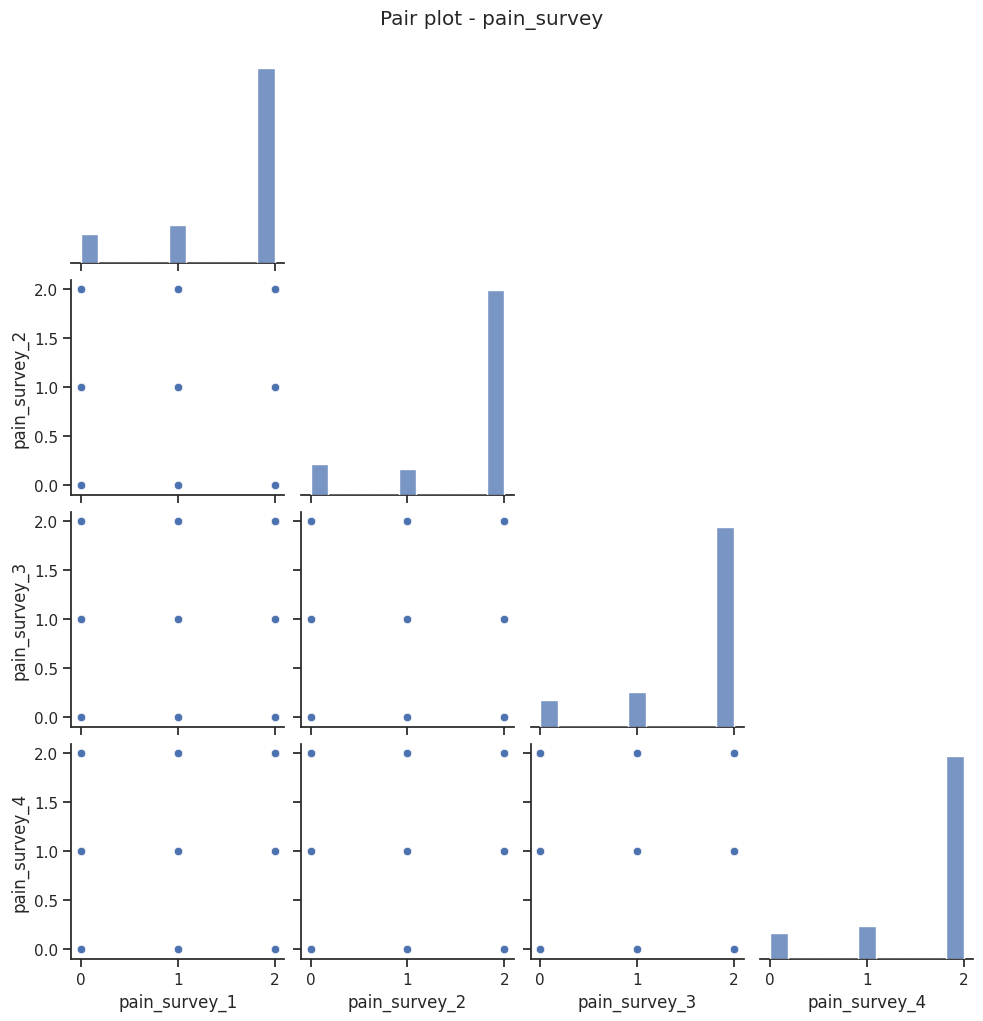

Saved figures/pairplot_n_things.png


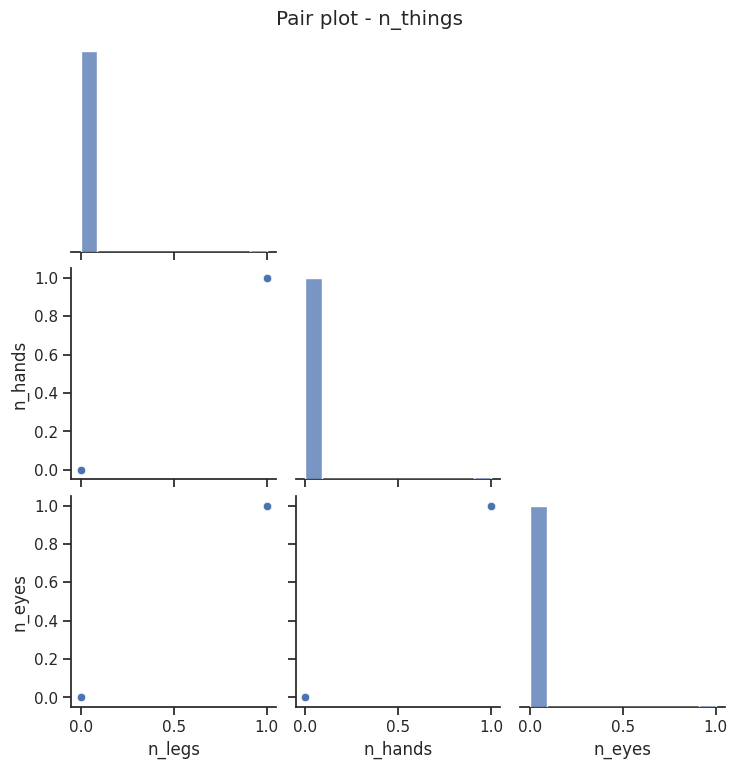

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7eb1c2a64d60> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7eb1a3321940> (for post_execute):


KeyboardInterrupt: 

In [9]:
pairplot_groups = [
    ("pain_survey", var_names.get("pain_survey", [])),
    ("n_things", var_names.get("n_things", [])),
    ("joint", var_names.get("joint", []))

]

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)
max_rows = 1000

for group_name, cols in pairplot_groups:
    columns = [col for col in cols if col in df.columns]
    if len(columns) < 2:
        print(f"Skipping {group_name} (need at least two columns, got {columns}).")
        continue

    plot_data = df[columns].dropna()
    if len(plot_data) > max_rows:
        plot_data = plot_data.sample(max_rows, random_state=0)

    pair_grid = sns.pairplot(plot_data, corner=True, diag_kind="hist")
    pair_grid.fig.suptitle(f"Pair plot - {group_name}", y=1.02)

    png_path = output_dir / f"pairplot_{group_name}.png"
    pair_grid.fig.savefig(png_path, dpi=180, bbox_inches="tight")
    print(f"Saved {png_path}")
    plt.show()
    plt.close(pair_grid.fig)


# Considerations
- All n_things variables are the same
- joint30 is constant
- joint22 is near constant

In [ ]:
df.loc[(df["n_hands"]==1) & (df["n_legs"]==1) & (df["n_eyes"]==1)]

df["joint_22"]

## Correlation matrix


,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,joint_01,joint_02,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
pain_survey_1,1.000000,0.049383,0.061059,0.035654,-0.007217,-0.007217,-0.007217,0.103713,0.084278,0.029241,...,-0.011499,-0.006968,-0.014547,-0.029130,-0.010986,-0.200999,-0.145457,-0.123563,-0.091091,NaN
pain_survey_2,0.049383,1.000000,0.034670,0.049749,-0.010966,-0.010966,-0.010966,0.056456,0.070261,0.007181,...,-0.011020,-0.002779,-0.009420,-0.015870,-0.010509,-0.122458,-0.131266,-0.068209,-0.121142,NaN
pain_survey_3,0.061059,0.034670,1.000000,0.034950,-0.001121,-0.001121,-0.001121,0.029542,0.031905,0.002053,...,-0.013557,-0.013987,-0.024345,-0.087135,-0.021339,-0.156563,-0.109419,-0.126796,-0.068723,NaN
pain_survey_4,0.035654,0.049749,0.034950,1.000000,-0.001146,-0.001146,-0.001146,0.030696,0.021393,0.007098,...,-0.009619,-0.010228,-0.035106,-0.046318,-0.019288,-0.094217,-0.114414,-0.056889,-0.135766,NaN
n_legs,-0.007217,-0.010966,-0.001121,-0.001146,1.000000,1.000000,1.000000,-0.075939,-0.078198,-0.082446,...,-0.000414,0.003158,-0.000401,-0.001842,0.003377,-0.000976,-0.003762,-0.018145,-0.016985,NaN
n_hands,-0.007217,-0.010966,-0.001121,-0.001146,1.000000,1.000000,1.000000,-0.075939,-0.078198,-0.082446,...,-0.000414,0.003158,-0.000401,-0.001842,0.003377,-0.000976,-0.003762,-0.018145,-0.016985,NaN
n_eyes,-0.007217,-0.010966,-0.001121,-0.001146,1.000000,1.000000,1.000000,-0.075939,-0.078198,-0.082446,...,-0.000414,0.003158,-0.000401,-0.001842,0.003377,-0.000976,-0.003762,-0.018145,-0.016985,NaN
joint_00,0.103713,0.056456,0.029542,0.030696,-0.075939,-0.075939,-0.075939,1.000000,0.764235,0.844885,...,-0.003401,-0.002864,0.005221,-0.004372,-0.007911,-0.158888,-0.105230,0.097553,0.011481,NaN
joint_01,0.084278,0.070261,0.031905,0.021393,-0.078198,-0.078198,-0.078198,0.764235,1.000000,0.680542,...,-0.005190,-0.003021,0.004014,-0.009068,-0.012745,-0.128563,-0.053939,0.003141,0.005710,NaN
joint_02,0.029241,0.007181,0.002053,0.007098,-0.082446,-0.082446,-0.082446,0.844885,0.680542,1.000000,...,0.001481,0.002007,0.006254,-0.001782,-0.001266,-0.053537,-0.014122,0.136478,0.046727,NaN


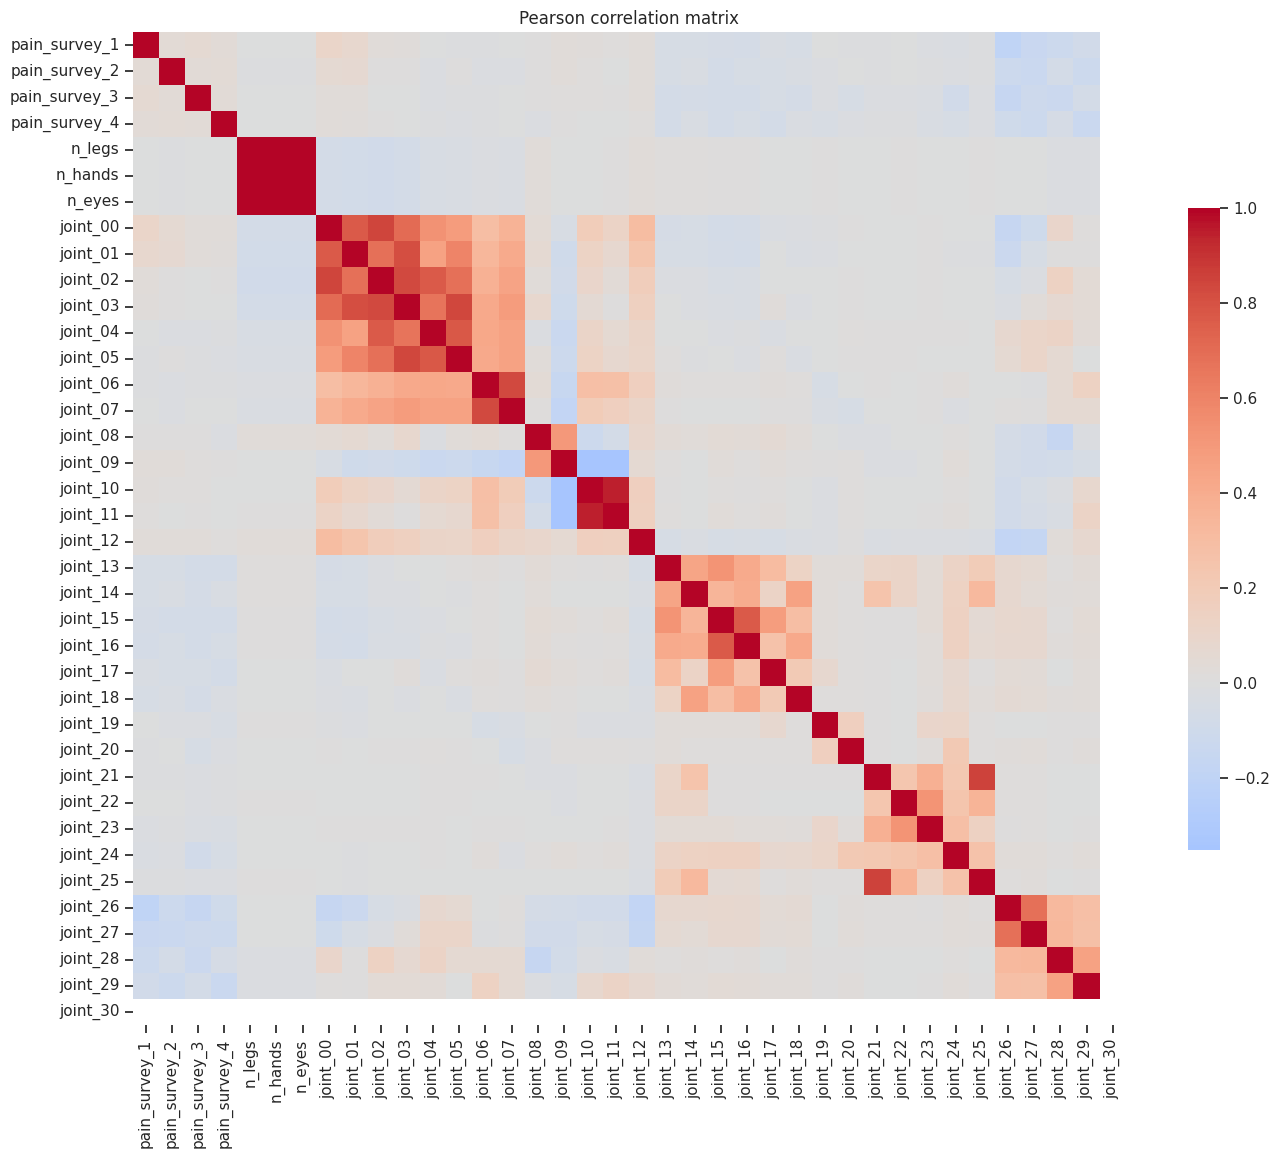

In [14]:
corr_columns = (
    var_names.get("pain_survey", [])
    + var_names.get("n_things", [])
    + var_names.get("joint", [])
)

corr_columns = [col for col in corr_columns if col in df.columns]

corr_matrix = df[corr_columns].corr(method="pearson")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.6},
)
plt.title("Pearson correlation matrix")
plt.tight_layout()

corr_matrix


# Let's analyze the correlation between the pain_survay

In [ ]:
# Compute Cramér's V between all pairs of categorical variables
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ((confusion_matrix - confusion_matrix.mean()) ** 2 / confusion_matrix.mean()).sum().sum()
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Compute pairwise matrix
pain_cols = [col for col in df.columns if col.startswith("pain_survey_")]
df_pain = df[pain_cols]

cols = df_pain.columns
n = len(cols)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix[i, j] = cramers_v(df_pain[cols[i]], df_pain[cols[j]])

cramer_df = pd.DataFrame(matrix, index=cols, columns=cols)
import matplotlib.pyplot as plt

plt.matshow(cramer_df, cmap="viridis")
plt.xticks(range(n), cols, rotation=45, ha="left")
plt.yticks(range(n), cols)
plt.colorbar(label="Cramér's V")
plt.title("Cramér's V Association Matrix for Pain Survey Variables", pad=20)
plt.show()

cramer_df

#Show Time series

In [10]:
df_labels = pd.read_csv("pirate_pain_train_labels.csv")
df = pd.merge(df, df_labels, on="sample_index", how="left")
df.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,0,0,0,1.094705,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,0,0,0,1.135183,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,0,0,0,1.080745,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,0,0,0,0.938017,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,0,0,0,1.090185,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain


## Generate Time Series Plots

In [11]:
plot_variables = [
    col for col in var_names.get("pain_survey", [])
    + var_names.get("joint", [])
    if col != "joint_30"
]

time_series_output_dir = Path("figures/time_series")
time_series_output_dir.mkdir(exist_ok=True)

for variable in plot_variables:
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df,
        x="time",
        y=variable,
        units="sample_index",
        estimator=None, # Plot individual lines per sample
        hue="label",
        palette="viridis",
        alpha=0.6
    )
    plt.title(f"Time Series of {variable} by Label")
    plt.xlabel("Time")
    plt.ylabel(variable)
    plt.tight_layout()
    png_path = time_series_output_dir / f"time_series_{variable}.png"
    plt.savefig(png_path, dpi=180, bbox_inches="tight")
    print(f"Saved {png_path}")
    plt.close() # Close the plot to free up memory


Saved figures/time_series/time_series_pain_survey_1.png
Saved figures/time_series/time_series_pain_survey_2.png
Saved figures/time_series/time_series_pain_survey_3.png
Saved figures/time_series/time_series_pain_survey_4.png
Saved figures/time_series/time_series_joint_00.png
Saved figures/time_series/time_series_joint_01.png
Saved figures/time_series/time_series_joint_02.png
Saved figures/time_series/time_series_joint_03.png
Saved figures/time_series/time_series_joint_04.png
Saved figures/time_series/time_series_joint_05.png
Saved figures/time_series/time_series_joint_06.png
Saved figures/time_series/time_series_joint_07.png
Saved figures/time_series/time_series_joint_08.png
Saved figures/time_series/time_series_joint_09.png
Saved figures/time_series/time_series_joint_10.png
Saved figures/time_series/time_series_joint_11.png
Saved figures/time_series/time_series_joint_12.png
Saved figures/time_series/time_series_joint_13.png
Saved figures/time_series/time_series_joint_14.png
Saved figur

In [22]:
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}
df['label'] = df['label'].map(label_mapping)
df.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,0,0,0,1.094705,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0
1,0,1,2,2,2,2,0,0,0,1.135183,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0
2,0,2,2,0,2,2,0,0,0,1.080745,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,0
3,0,3,2,2,2,2,0,0,0,0.938017,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,0
4,0,4,2,2,2,2,0,0,0,1.090185,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,0


,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,joint_01,joint_02,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label
pain_survey_1,1.000000,0.049383,0.061059,0.035654,-0.007217,-0.007217,-0.007217,0.103713,0.084278,0.029241,...,-0.011499,-0.006968,-0.014547,-0.029130,-0.010986,-0.200999,-0.145457,-0.123563,-0.091091,-0.129585
pain_survey_2,0.049383,1.000000,0.034670,0.049749,-0.010966,-0.010966,-0.010966,0.056456,0.070261,0.007181,...,-0.011020,-0.002779,-0.009420,-0.015870,-0.010509,-0.122458,-0.131266,-0.068209,-0.121142,-0.107144
pain_survey_3,0.061059,0.034670,1.000000,0.034950,-0.001121,-0.001121,-0.001121,0.029542,0.031905,0.002053,...,-0.013557,-0.013987,-0.024345,-0.087135,-0.021339,-0.156563,-0.109419,-0.126796,-0.068723,-0.075306
pain_survey_4,0.035654,0.049749,0.034950,1.000000,-0.001146,-0.001146,-0.001146,0.030696,0.021393,0.007098,...,-0.009619,-0.010228,-0.035106,-0.046318,-0.019288,-0.094217,-0.114414,-0.056889,-0.135766,-0.065369
n_legs,-0.007217,-0.010966,-0.001121,-0.001146,1.000000,1.000000,1.000000,-0.075939,-0.078198,-0.082446,...,-0.000414,0.003158,-0.000401,-0.001842,0.003377,-0.000976,-0.003762,-0.018145,-0.016985,-0.022394
n_hands,-0.007217,-0.010966,-0.001121,-0.001146,1.000000,1.000000,1.000000,-0.075939,-0.078198,-0.082446,...,-0.000414,0.003158,-0.000401,-0.001842,0.003377,-0.000976,-0.003762,-0.018145,-0.016985,-0.022394
n_eyes,-0.007217,-0.010966,-0.001121,-0.001146,1.000000,1.000000,1.000000,-0.075939,-0.078198,-0.082446,...,-0.000414,0.003158,-0.000401,-0.001842,0.003377,-0.000976,-0.003762,-0.018145,-0.016985,-0.022394
joint_00,0.103713,0.056456,0.029542,0.030696,-0.075939,-0.075939,-0.075939,1.000000,0.764235,0.844885,...,-0.003401,-0.002864,0.005221,-0.004372,-0.007911,-0.158888,-0.105230,0.097553,0.011481,-0.135058
joint_01,0.084278,0.070261,0.031905,0.021393,-0.078198,-0.078198,-0.078198,0.764235,1.000000,0.680542,...,-0.005190,-0.003021,0.004014,-0.009068,-0.012745,-0.128563,-0.053939,0.003141,0.005710,-0.103478
joint_02,0.029241,0.007181,0.002053,0.007098,-0.082446,-0.082446,-0.082446,0.844885,0.680542,1.000000,...,0.001481,0.002007,0.006254,-0.001782,-0.001266,-0.053537,-0.014122,0.136478,0.046727,0.005184


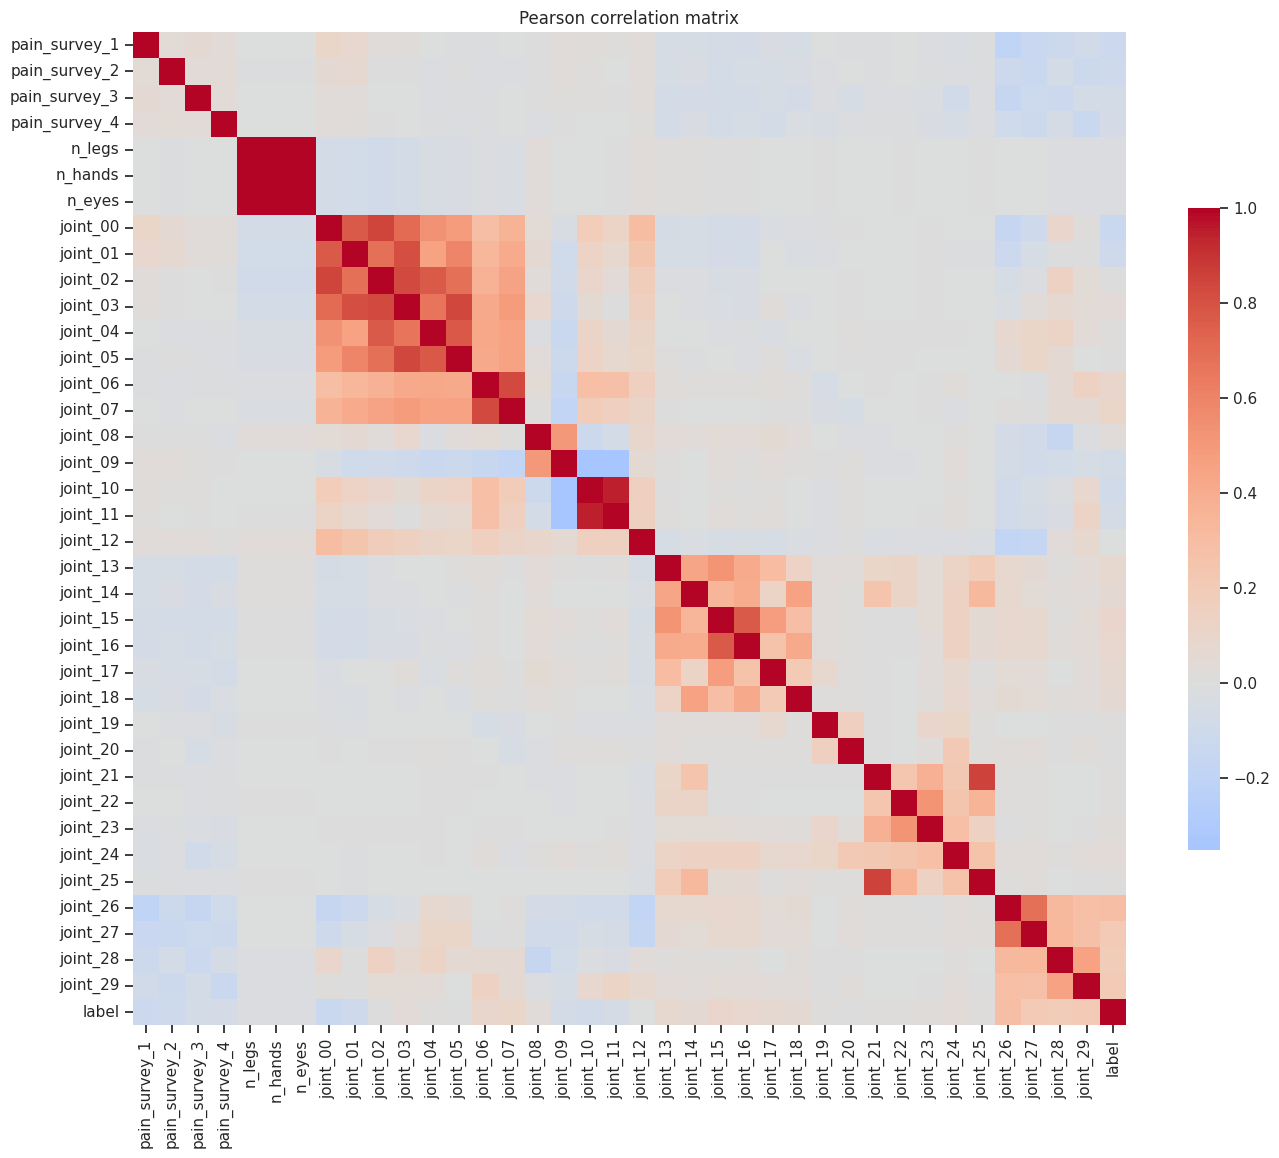

In [24]:
corr_columns = (
    var_names.get("pain_survey", [])
    + var_names.get("n_things", [])
    + var_names.get("joint", [])
)

corr_columns = [col for col in corr_columns if col in df.columns]
corr_columns.remove("joint_30")
corr_columns.append("label")

corr_matrix = df[corr_columns].corr(method="pearson")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.6},
)
plt.title("Pearson correlation matrix")
plt.tight_layout()

corr_matrix

Saved figures/pairplot_pain_survey.png


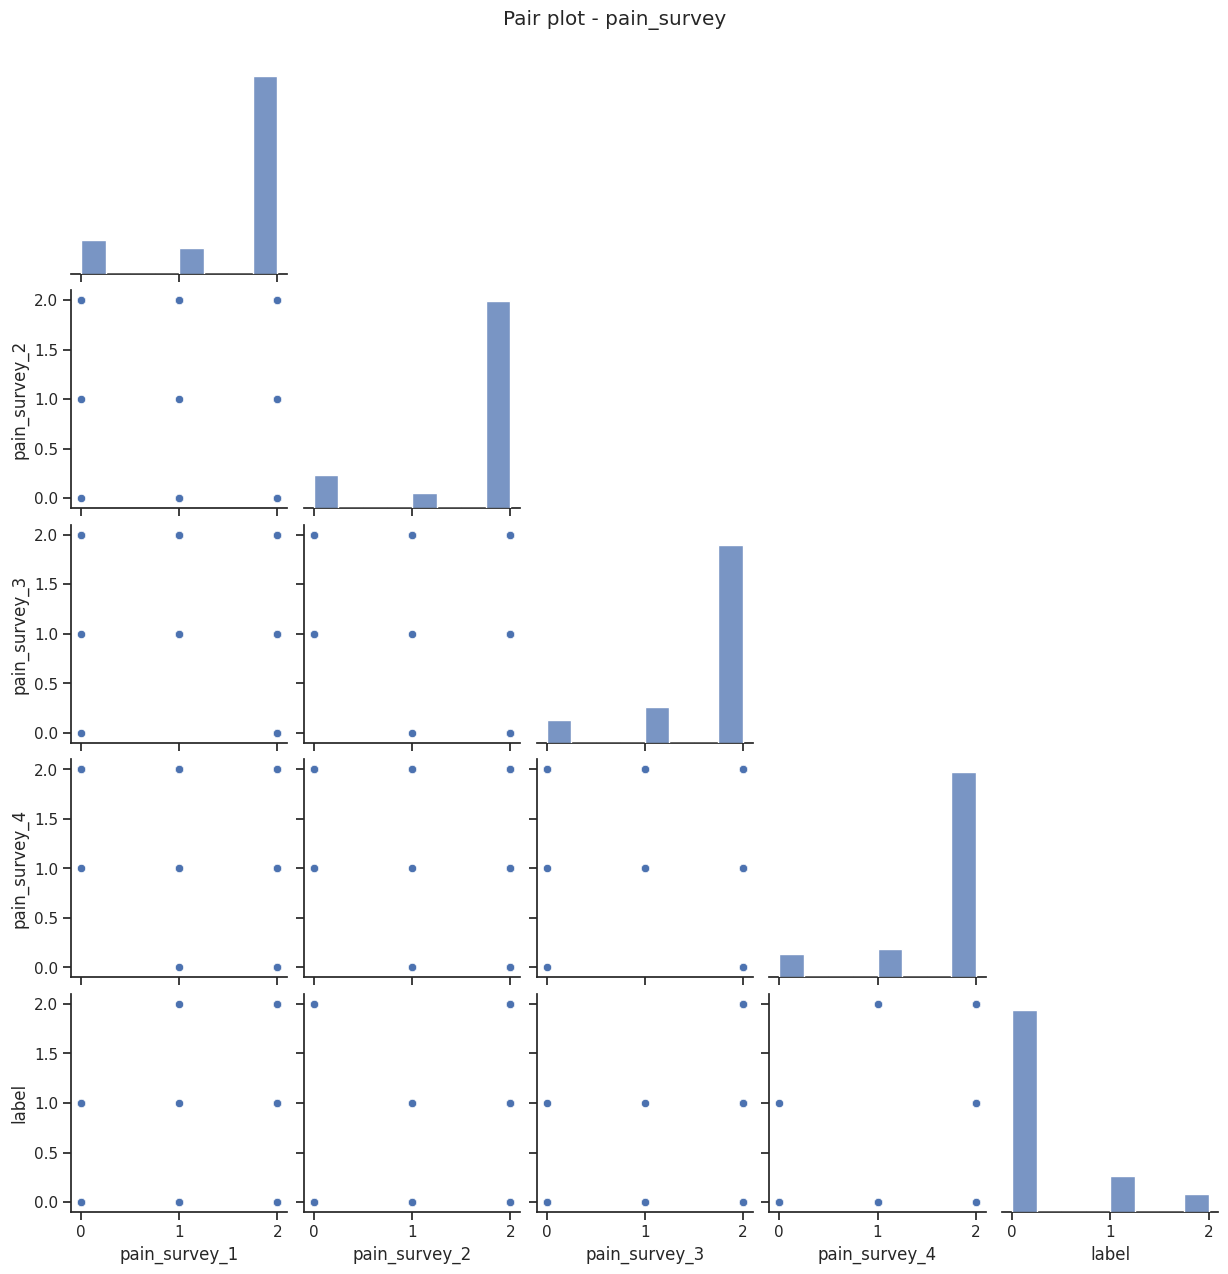

Saved figures/pairplot_n_things.png


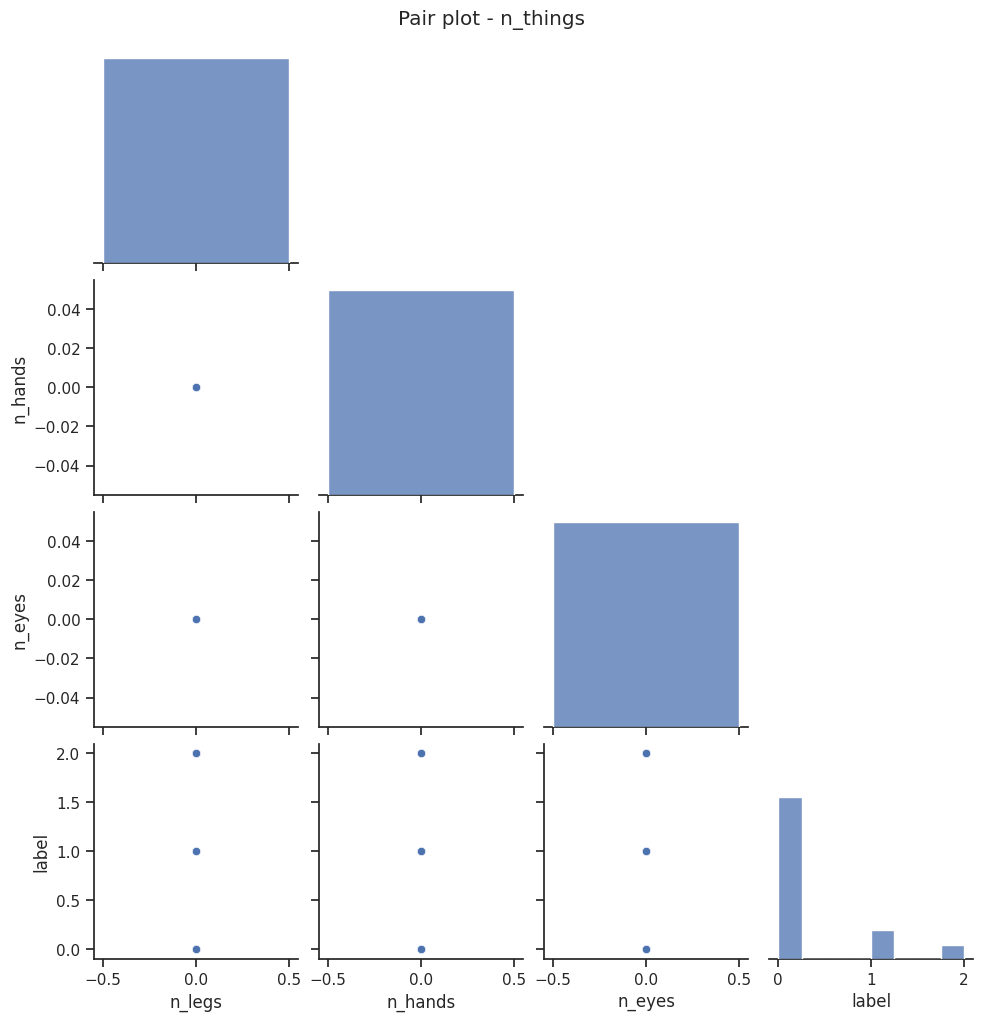

Saved figures/pairplot_joint.png


In [28]:
pairplot_groups = [
    ("pain_survey", var_names.get("pain_survey", [])),
    ("n_things", var_names.get("n_things", [])),
    ("joint", var_names.get("joint", []))
]

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)
max_rows = 100

for group_name, cols in pairplot_groups:
    columns = [col for col in cols if col in df.columns]
    columns.append("label")
    if len(columns) < 2:
        print(f"Skipping {group_name} (need at least two columns, got {columns}).")
        continue

    plot_data = df[columns].dropna()
    if len(plot_data) > max_rows:
        plot_data = plot_data.sample(max_rows, random_state=0)

    pair_grid = sns.pairplot(plot_data, corner=True, diag_kind="hist")
    pair_grid.fig.suptitle(f"Pair plot - {group_name}", y=1.02)

    png_path = output_dir / f"pairplot_{group_name}.png"
    pair_grid.fig.savefig(png_path, dpi=180, bbox_inches="tight")
    print(f"Saved {png_path}")
    plt.show()
    plt.close(pair_grid.fig)


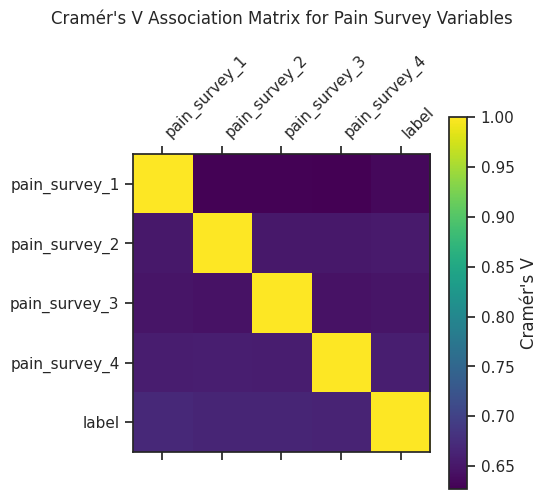

,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,label
pain_survey_1,1.000000,0.628606,0.629821,0.627112,0.634610
pain_survey_2,0.651388,1.000000,0.650732,0.651697,0.653983
pain_survey_3,0.647525,0.645722,1.000000,0.645574,0.647954
pain_survey_4,0.656950,0.658417,0.657273,1.000000,0.658234
label,0.669488,0.666155,0.665441,0.663907,1.000000


In [29]:
# Compute Cramér's V between all pairs of categorical variables
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ((confusion_matrix - confusion_matrix.mean()) ** 2 / confusion_matrix.mean()).sum().sum()
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Compute pairwise matrix
pain_cols = [col for col in df.columns if col.startswith("pain_survey_")]
pain_cols.append("label")
df_pain = df[pain_cols]

cols = df_pain.columns
n = len(cols)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix[i, j] = cramers_v(df_pain[cols[i]], df_pain[cols[j]])

cramer_df = pd.DataFrame(matrix, index=cols, columns=cols)
import matplotlib.pyplot as plt

plt.matshow(cramer_df, cmap="viridis")
plt.xticks(range(n), cols, rotation=45, ha="left")
plt.yticks(range(n), cols)
plt.colorbar(label="Cramér's V")
plt.title("Cramér's V Association Matrix for Pain Survey Variables", pad=20)
plt.show()

cramer_df

## Summary:

### Data Analysis Key Findings
*   Time series plots were generated for all `pain_survey` and `joint` variables (excluding `joint_30`), totaling a number of plots equal to the sum of `pain_survey` variables and `joint` variables minus one.
*   Each plot displayed 'time' on the x-axis and the respective variable on the y-axis, with individual lines plotted for each `sample_index`.
*   Lines in the plots were colored according to the 'label' column, allowing for visual comparison of time series behavior between different label groups.
*   All generated plots were saved as PNG files in the `figures/time_series` directory.
